# Analysing data

### Libraries

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import plotly.express as px
import geopandas as gpd # NEEDS Installation of geopandas and its dependencies. Run # pip install geopandas in your terminal
import plotly.graph_objects as go
import pycountry
import geodatasets #NEEDS INSTALLATION of geodatasets. Run # pip install geodatasets in your terminal


### World bank data

In [27]:
#Import from worldbank.ipynb to get the world_bank_pivot dataframe, which contains the GDP per capita data for different countries and years. We will use this data to analyze the relationship between GDP per capita and job creation in our jobs dataset.

world_bank_pivot = pd.read_csv("world_bank_data.csv")
world_bank_pivot.head(10)


,country,gdp_per_capita,inflation_cpi,population,unemployment_rate,youth_unemployment
0,Austria,58268.878765,2.937916,9177982.0,5.200,10.864
1,Belgium,56614.567950,3.143491,11858610.0,5.700,17.418
2,France,46103.084086,1.999049,68551653.0,7.400,19.342
3,Germany,56103.732318,2.256498,83516593.0,3.400,6.910
4,Italy,40385.341396,0.982373,58952704.0,6.500,20.316
5,Netherlands,67520.421896,3.347543,17993485.0,3.700,8.683
6,Poland,25103.565661,3.790609,36559233.0,2.807,10.656
7,Spain,35326.768307,2.774178,48848840.0,11.400,26.519
8,Switzerland,103998.186686,1.062340,9005582.0,4.343,8.231
9,United Kingdom,53246.367615,3.271573,69226000.0,4.361,14.290


### Jobs data

In [28]:
#First we load the cleaned jobs dataset to analyze it
jobs_df_clean = pd.read_csv("jobs_clean.csv")
jobs_df_clean.head()

,Unnamed: 0,id,title,contract_type,description,created,clean_country,clean_salary,extracted_skills,work_mode,...,clean_city,clean_company,title_clean,job_category,min_salary,max_salary,currency,exchange_rate,MIN_EUR,MAX_EUR
0,0,5753281217,Data Analyst (m/w/d),NaN,Bei STRABAG bauen rund 89.000 Menschen an mehr...,2026-06-05 16:40:19,AT,Not Found,"GIT, OTHER",Remote,...,Österreich,STRABAG BRVZ GMBH,data analyst (m/w/d),data analyst,Not Found,NaN,EUR,1.0,NaN,NaN
1,1,5753281216,Data Analyst (m/w/d),NaN,Bei STRABAG bauen rund 89.000 Menschen an mehr...,2026-06-05 16:40:19,AT,Not Found,"GIT, OTHER",Remote,...,Spittal an der Drau,STRABAG BRVZ GMBH,data analyst (m/w/d),data analyst,Not Found,NaN,EUR,1.0,NaN,NaN
2,2,5762094132,Data Analyst - MS PowerBI (m/w/d),NaN,Baustoff + Metall ist ein hoch spezialisierter...,2026-06-13 06:58:14,AT,Not Found,"SQL, OTHER",Unspecified,...,"Wien, Österreich",Baustoff + Metall Gesellschaft m.b.H. Österrei...,data analyst ms powerbi (m/w/d),data analyst,Not Found,NaN,EUR,1.0,NaN,NaN
3,3,5727781690,Data Analyst (m/w/d),permanent,Data Analyst (m/w/d)\nJobs fürs Leben\nAuf der...,2026-05-13 08:03:25,AT,Not Found,SQL,Onsite,...,"Josefstadt, Wien",ÖSW Österreichisches Siedlungswerk Gemeinnützi...,data analyst (m/w/d),data analyst,Not Found,NaN,EUR,1.0,NaN,NaN
4,4,5758608143,Data Analyst,NaN,"What are you working on?\nGenres: Casual, Puzz...",2026-06-10 17:18:19,AT,Not Found,"PYTHON, SQL, TABLEAU, LOOKER",Unspecified,...,Österreich,Hitapps,data analyst,data analyst,Not Found,NaN,EUR,1.0,NaN,NaN


In [29]:
jobs_df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6518 entries, 0 to 6517
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          6518 non-null   int64  
 1   id                  6518 non-null   int64  
 2   title               6518 non-null   object 
 3   contract_type       1628 non-null   object 
 4   description         6518 non-null   object 
 5   created             6518 non-null   object 
 6   clean_country       6518 non-null   object 
 7   clean_salary        6518 non-null   object 
 8   extracted_skills    6518 non-null   object 
 9   work_mode           6518 non-null   object 
 10  seniority_level     6518 non-null   object 
 11  extracted_contract  6518 non-null   object 
 12  year_week           6518 non-null   object 
 13  clean_city          6518 non-null   object 
 14  clean_company       6518 non-null   object 
 15  title_clean         6518 non-null   object 
 16  job_ca

#### Filtering data to 2026

In [30]:
#Let's filter the jobs dataset to only include jobs created in 2026, 
#as we are interested in analyzing the job market for that year.
jobs_df_clean["created"] = (
    pd.to_datetime( jobs_df_clean["created"], errors="coerce", utc=True)
    .dt.tz_localize(None))

jobs_2026 = jobs_df_clean[jobs_df_clean["created"].dt.year == 2026]
jobs_2026.head()

,Unnamed: 0,id,title,contract_type,description,created,clean_country,clean_salary,extracted_skills,work_mode,...,clean_city,clean_company,title_clean,job_category,min_salary,max_salary,currency,exchange_rate,MIN_EUR,MAX_EUR
0,0,5753281217,Data Analyst (m/w/d),NaN,Bei STRABAG bauen rund 89.000 Menschen an mehr...,2026-06-05 16:40:19,AT,Not Found,"GIT, OTHER",Remote,...,Österreich,STRABAG BRVZ GMBH,data analyst (m/w/d),data analyst,Not Found,NaN,EUR,1.0,NaN,NaN
1,1,5753281216,Data Analyst (m/w/d),NaN,Bei STRABAG bauen rund 89.000 Menschen an mehr...,2026-06-05 16:40:19,AT,Not Found,"GIT, OTHER",Remote,...,Spittal an der Drau,STRABAG BRVZ GMBH,data analyst (m/w/d),data analyst,Not Found,NaN,EUR,1.0,NaN,NaN
2,2,5762094132,Data Analyst - MS PowerBI (m/w/d),NaN,Baustoff + Metall ist ein hoch spezialisierter...,2026-06-13 06:58:14,AT,Not Found,"SQL, OTHER",Unspecified,...,"Wien, Österreich",Baustoff + Metall Gesellschaft m.b.H. Österrei...,data analyst ms powerbi (m/w/d),data analyst,Not Found,NaN,EUR,1.0,NaN,NaN
3,3,5727781690,Data Analyst (m/w/d),permanent,Data Analyst (m/w/d)\nJobs fürs Leben\nAuf der...,2026-05-13 08:03:25,AT,Not Found,SQL,Onsite,...,"Josefstadt, Wien",ÖSW Österreichisches Siedlungswerk Gemeinnützi...,data analyst (m/w/d),data analyst,Not Found,NaN,EUR,1.0,NaN,NaN
4,4,5758608143,Data Analyst,NaN,"What are you working on?\nGenres: Casual, Puzz...",2026-06-10 17:18:19,AT,Not Found,"PYTHON, SQL, TABLEAU, LOOKER",Unspecified,...,Österreich,Hitapps,data analyst,data analyst,Not Found,NaN,EUR,1.0,NaN,NaN


In [31]:
# Further filter to only include data analyst jobs
data_analyst_jobs = jobs_2026[jobs_2026["job_category"].str.lower() == "data analyst"].copy()

data_analyst_jobs.head()


,Unnamed: 0,id,title,contract_type,description,created,clean_country,clean_salary,extracted_skills,work_mode,...,clean_city,clean_company,title_clean,job_category,min_salary,max_salary,currency,exchange_rate,MIN_EUR,MAX_EUR
0,0,5753281217,Data Analyst (m/w/d),NaN,Bei STRABAG bauen rund 89.000 Menschen an mehr...,2026-06-05 16:40:19,AT,Not Found,"GIT, OTHER",Remote,...,Österreich,STRABAG BRVZ GMBH,data analyst (m/w/d),data analyst,Not Found,NaN,EUR,1.0,NaN,NaN
1,1,5753281216,Data Analyst (m/w/d),NaN,Bei STRABAG bauen rund 89.000 Menschen an mehr...,2026-06-05 16:40:19,AT,Not Found,"GIT, OTHER",Remote,...,Spittal an der Drau,STRABAG BRVZ GMBH,data analyst (m/w/d),data analyst,Not Found,NaN,EUR,1.0,NaN,NaN
2,2,5762094132,Data Analyst - MS PowerBI (m/w/d),NaN,Baustoff + Metall ist ein hoch spezialisierter...,2026-06-13 06:58:14,AT,Not Found,"SQL, OTHER",Unspecified,...,"Wien, Österreich",Baustoff + Metall Gesellschaft m.b.H. Österrei...,data analyst ms powerbi (m/w/d),data analyst,Not Found,NaN,EUR,1.0,NaN,NaN
3,3,5727781690,Data Analyst (m/w/d),permanent,Data Analyst (m/w/d)\nJobs fürs Leben\nAuf der...,2026-05-13 08:03:25,AT,Not Found,SQL,Onsite,...,"Josefstadt, Wien",ÖSW Österreichisches Siedlungswerk Gemeinnützi...,data analyst (m/w/d),data analyst,Not Found,NaN,EUR,1.0,NaN,NaN
4,4,5758608143,Data Analyst,NaN,"What are you working on?\nGenres: Casual, Puzz...",2026-06-10 17:18:19,AT,Not Found,"PYTHON, SQL, TABLEAU, LOOKER",Unspecified,...,Österreich,Hitapps,data analyst,data analyst,Not Found,NaN,EUR,1.0,NaN,NaN


# Research questions

### 1 - Which countries have the most data analyst job postings?

In [32]:
jobs_per_country = (
    data_analyst_jobs.groupby("clean_country")
    .size()
    .reset_index(name="Data Analyst Jobs")
    .sort_values("Data Analyst Jobs", ascending=False)
    .reset_index(drop=True)  
)

jobs_per_country

,clean_country,Data Analyst Jobs
0,FR,763
1,GB,645
2,PL,310
3,DE,282
4,IT,144
5,ES,131
6,NL,89
7,BE,55
8,CH,27
9,AT,21


In [33]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd

# 2. Count jobs per country
jobs_per_country = (
    data_analyst_jobs.groupby("clean_country")
    .size()
    .reset_index(name="Jobs")
    .sort_values("Jobs", ascending=False)
    .reset_index(drop=True)
)

# 3. Convert ISO-2 to ISO-3
iso2_to_iso3 = {
    "FR": "FRA",
    "GB": "GBR",
    "PL": "POL",
    "DE": "DEU",
    "IT": "ITA",
    "ES": "ESP",
    "NL": "NLD",
    "BE": "BEL",
    "CH": "CHE",
    "AT": "AUT"
}

# 4. Full country names
country_names = {
    "FR": "France",
    "GB": "United Kingdom",
    "PL": "Poland",
    "DE": "Germany",
    "IT": "Italy",
    "ES": "Spain",
    "NL": "Netherlands",
    "BE": "Belgium",
    "CH": "Switzerland",
    "AT": "Austria"
}

# Approximate label positions
country_centers = {
    "FRA": {"lat": 46.2, "lon": 2.2},
    "GBR": {"lat": 52.8, "lon": -2.0},
    "POL": {"lat": 52.1, "lon": 19.4},
    "DEU": {"lat": 51.2, "lon": 10.4},
    "ITA": {"lat": 42.8, "lon": 12.8},
    "ESP": {"lat": 40.3, "lon": -3.7},
    "NLD": {"lat": 52.3, "lon": 5.3},
    "BEL": {"lat": 50.8, "lon": 4.4},
    "CHE": {"lat": 46.8, "lon": 8.2},
    "AUT": {"lat": 47.6, "lon": 14.1}
}

jobs_per_country["iso3"] = jobs_per_country["clean_country"].map(iso2_to_iso3)
jobs_per_country["country_name"] = jobs_per_country["clean_country"].map(country_names)
jobs_per_country["lat"] = jobs_per_country["iso3"].map(lambda x: country_centers[x]["lat"])
jobs_per_country["lon"] = jobs_per_country["iso3"].map(lambda x: country_centers[x]["lon"])
jobs_per_country["label"] = jobs_per_country["Jobs"].astype(str)

# 5. Meteo-style gradient
meteo_scale = [
    [0.00, "#2c7bb6"],
    [0.25, "#00a668"],
    [0.50, "#f6e84a"],
    [0.75, "#f46d43"],
    [1.00, "#6a0dad"]
]

# 6. Create choropleth map
fig = px.choropleth(
    jobs_per_country,
    locations="iso3",
    color="Jobs",
    hover_name="country_name",
    hover_data={
        "iso3": False,
        "clean_country": False,
        "Jobs": True
    },
    color_continuous_scale=meteo_scale,
    title="Data Analyst Jobs by Country (2026)",
    scope="europe"
)

# 7. Add text labels on top
fig.add_trace(
    go.Scattergeo(
        lon=jobs_per_country["lon"],
        lat=jobs_per_country["lat"],
        text=jobs_per_country["label"],
        mode="text",
        textfont=dict(size=12, color="white"),
        hoverinfo="skip",
        showlegend=False
    )
)

# 8. Add footnote
fig.add_annotation(
    text="Jobs posted on adzuna.com for the European countries where it is available.",
    xref="paper",
    yref="paper",
    x=0,
    y=-0.12,
    showarrow=False,
    font=dict(size=12, color="gray"),
    align="left"
)

# 9. Layout
fig.update_layout(
    coloraxis_colorbar_title="Jobs",
    margin=dict(r=0, t=60, l=0, b=90)
)

fig.show()


In [34]:
# Share of Data Analyst jobs over ALL jobs (2026)

# Overall
total_jobs = len(jobs_2026)
da_jobs = len(data_analyst_jobs)
overall_pct = da_jobs / total_jobs * 100
print(f"Data Analyst jobs: {da_jobs} / {total_jobs} total jobs = {overall_pct:.1f}%")

# Per country
all_per_country = jobs_2026.groupby("clean_country").size()
da_per_country = data_analyst_jobs.groupby("clean_country").size()

da_share = (
    pd.DataFrame({"all_jobs": all_per_country, "data_analyst_jobs": da_per_country})
    .fillna(0)
    .astype({"all_jobs": int, "data_analyst_jobs": int})
    .assign(da_pct=lambda d: (d["data_analyst_jobs"] / d["all_jobs"] * 100).round(1))
    .sort_values("da_pct", ascending=False)
    .reset_index()
    .rename(columns={"clean_country": "country"})
)

da_share

Data Analyst jobs: 2467 / 5896 total jobs = 41.8%


,country,all_jobs,data_analyst_jobs,da_pct
0,ES,203,131,64.5
1,IT,242,144,59.5
2,PL,576,310,53.8
3,CH,61,27,44.3
4,DE,640,282,44.1
5,FR,1864,763,40.9
6,AT,52,21,40.4
7,GB,1784,645,36.2
8,BE,171,55,32.2
9,NL,303,89,29.4


### 2 - Which countries offer the best overall opportunity (salary + economic context)?

In [56]:
# copy only what we need
jobs_salary = data_analyst_jobs[["clean_country", "MIN_EUR", "MAX_EUR"]].copy()

country_map = {
    "FR": "France",
    "GB": "United Kingdom",
    "DE": "Germany",
    "NL": "Netherlands",
    "BE": "Belgium",
    "ES": "Spain",
    "IT": "Italy",
    "PL": "Poland",
    "CH": "Switzerland",
    "AT": "Austria"
}

jobs_salary["country"] = jobs_salary["clean_country"].replace(country_map)

# salary available or not
jobs_salary["has_salary"] = jobs_salary["MIN_EUR"].notna() | jobs_salary["MAX_EUR"].notna()

# aggregate by country
salary_by_country = (
    jobs_salary.groupby("country", as_index=False)
    .agg(
        total_jobs=("country", "size"),
        salary_jobs=("has_salary", "sum"),
        avg_min_salary=("MIN_EUR", "mean"),
        avg_max_salary=("MAX_EUR", "mean")
    )
)

salary_by_country["salary_coverage"] = (
    salary_by_country["salary_jobs"] / salary_by_country["total_jobs"]
)

salary_by_country["avg_salary"] = (
    salary_by_country["avg_min_salary"] + salary_by_country["avg_max_salary"]
) / 2

# merge with World Bank data
opportunity_df = salary_by_country.merge(
    world_bank_pivot,
    on="country",
    how="left"
)

opportunity_df["da_jobs_per_million_inhabitants"] = (
    opportunity_df["total_jobs"] / (opportunity_df["population"] / 1_000_000)
).round(1)



# keep only rows with needed data
opportunity_df = opportunity_df.dropna(
    subset=["avg_salary", "gdp_per_capita", "inflation_cpi", "unemployment_rate", "total_jobs", "population", "da_jobs_per_million_inhabitants"]
).copy()

# normalization helper
def norm(s):
    if s.max() == s.min():
        return pd.Series(0, index=s.index)
    return (s - s.min()) / (s.max() - s.min())

# normalized scores
opportunity_df["salary_score"] = norm(opportunity_df["avg_salary"])
opportunity_df["gdp_score"] = norm(opportunity_df["gdp_per_capita"])
opportunity_df["inflation_score"] = 1 - norm(opportunity_df["inflation_cpi"])
opportunity_df["unemployment_score"] = 1 - norm(opportunity_df["unemployment_rate"])

# market size score
opportunity_df["market_score"] = norm(opportunity_df["total_jobs"])

# adjust salary by coverage
opportunity_df["salary_score_adjusted"] = (
    opportunity_df["salary_score"] * opportunity_df["salary_coverage"]
)

# final score
opportunity_df["opportunity_score"] = (
    0.35 * opportunity_df["salary_score_adjusted"] +
    0.20 * opportunity_df["market_score"] +
    0.20 * opportunity_df["gdp_score"] +
    0.15 * opportunity_df["unemployment_score"] +
    0.10 * opportunity_df["inflation_score"]
)

# final table
best_countries = opportunity_df[[
    "country",
    "total_jobs",
    "da_jobs_per_million_inhabitants",
    "salary_coverage",
    "avg_salary",
    "gdp_per_capita",
    "unemployment_rate",
    "inflation_cpi",
    "opportunity_score"
    
]].sort_values("opportunity_score", ascending=False)

# leave one decimal
best_countries = best_countries.round(1)

best_countries.head(10)


,country,total_jobs,da_jobs_per_million_inhabitants,salary_coverage,avg_salary,gdp_per_capita,unemployment_rate,inflation_cpi,opportunity_score
9,United Kingdom,645,9.3,1.0,59105.5,53246.4,4.4,3.3,0.6
8,Switzerland,27,3.0,0.0,56500.0,103998.2,4.3,1.1,0.4
2,France,763,11.1,0.2,27909.5,46103.1,7.4,2.0,0.4
3,Germany,282,3.4,0.1,80893.4,56103.7,3.4,2.3,0.4
5,Netherlands,89,4.9,0.4,41797.1,67520.4,3.7,3.3,0.4
6,Poland,310,8.5,0.4,53822.1,25103.6,2.8,3.8,0.3
4,Italy,144,2.4,0.2,23592.4,40385.3,6.5,1.0,0.3
0,Austria,21,2.3,0.2,39250.6,58268.9,5.2,2.9,0.3
1,Belgium,55,4.6,0.1,2834.2,56614.6,5.7,3.1,0.2
7,Spain,131,2.7,0.2,33748.4,35326.8,11.4,2.8,0.1


Opportunity score is a composite ranking that combines salary, market size, and macroeconomic conditions into one metric. Salary coverage measures the share of job postings that actually disclose pay, so lower coverage means the salary average is based on fewer observed postings and is therefore less reliable. Salary has the largest weight, but it is adjusted by coverage so countries with more transparent pay data are rewarded more fairly.

The score is weighted as 35% salary adjusted by coverage, 20% number of posts, 20% GDP per capita, 15% unemployment, and 10% inflation. This means the ranking favors countries that offer strong pay, a healthy job market, and stable economic conditions, while also accounting for how complete the salary data is.

In addition to raw job volume, the analysis also includes jobs per million inhabitants. This metric shows how dense the market is relative to population, which makes comparisons fairer between larger and smaller countries. A country with fewer total postings can still look attractive if demand is strong relative to its size.

The UK looks strongest because it combines a large number of listings, solid jobs-per-capita density, and comparatively good salary disclosure, so its score is supported by both market size and data quality. France also performs well because it has the biggest number of postings in your set and strong jobs-per-million, even though salary coverage is not very high, which means its salary signal should be read with some caution.

Switzerland is interesting: it has very high GDP per capita and strong economic fundamentals, but its score is pulled down by low market size and very limited salary disclosure. In other words, it looks like a high-quality market economically, but not necessarily the easiest one to enter based on posting volume alone.

Germany and the Netherlands still rank well because they combine decent market depth and strong country conditions, but their salary coverage is weaker, so salary-related conclusions should be treated as less stable. That does not mean they are bad markets; it means the ranking is correctly penalizing countries where the pay signal is thinner and less reliable.

### 3 - What skills are most requested, and how do they vary by country?

Top 10 skills by frequency (% of postings mentioning each skill)

Avg. number of skills requested per posting

In [36]:
# .assign(): Split the comma-separated string 'extracted_skills' into Python lists (e.g., "PYTHON, SQL" -> ["PYTHON", "SQL"])
# .explode(): Flatten the lists so each skill gets its own dedicated row, duplicating other row values accordingly
exploded_df = data_analyst_jobs.assign(extracted_skills=data_analyst_jobs["extracted_skills"].str.split(", ")).explode("extracted_skills")
# Use pivot_table to achieve the same cross-tabulation frequency count
pivot_skills = exploded_df.pivot_table(
    index="clean_country", 
    columns="extracted_skills", 
    values="id", 
    aggfunc="count"
)

In [37]:
#First we load the cleaned jobs dataset to analyze it
jobs_df_clean = pd.read_csv("jobs_clean.csv")
jobs_df_clean.head()

,Unnamed: 0,id,title,contract_type,description,created,clean_country,clean_salary,extracted_skills,work_mode,...,clean_city,clean_company,title_clean,job_category,min_salary,max_salary,currency,exchange_rate,MIN_EUR,MAX_EUR
0,0,5753281217,Data Analyst (m/w/d),NaN,Bei STRABAG bauen rund 89.000 Menschen an mehr...,2026-06-05 16:40:19,AT,Not Found,"GIT, OTHER",Remote,...,Österreich,STRABAG BRVZ GMBH,data analyst (m/w/d),data analyst,Not Found,NaN,EUR,1.0,NaN,NaN
1,1,5753281216,Data Analyst (m/w/d),NaN,Bei STRABAG bauen rund 89.000 Menschen an mehr...,2026-06-05 16:40:19,AT,Not Found,"GIT, OTHER",Remote,...,Spittal an der Drau,STRABAG BRVZ GMBH,data analyst (m/w/d),data analyst,Not Found,NaN,EUR,1.0,NaN,NaN
2,2,5762094132,Data Analyst - MS PowerBI (m/w/d),NaN,Baustoff + Metall ist ein hoch spezialisierter...,2026-06-13 06:58:14,AT,Not Found,"SQL, OTHER",Unspecified,...,"Wien, Österreich",Baustoff + Metall Gesellschaft m.b.H. Österrei...,data analyst ms powerbi (m/w/d),data analyst,Not Found,NaN,EUR,1.0,NaN,NaN
3,3,5727781690,Data Analyst (m/w/d),permanent,Data Analyst (m/w/d)\nJobs fürs Leben\nAuf der...,2026-05-13 08:03:25,AT,Not Found,SQL,Onsite,...,"Josefstadt, Wien",ÖSW Österreichisches Siedlungswerk Gemeinnützi...,data analyst (m/w/d),data analyst,Not Found,NaN,EUR,1.0,NaN,NaN
4,4,5758608143,Data Analyst,NaN,"What are you working on?\nGenres: Casual, Puzz...",2026-06-10 17:18:19,AT,Not Found,"PYTHON, SQL, TABLEAU, LOOKER",Unspecified,...,Österreich,Hitapps,data analyst,data analyst,Not Found,NaN,EUR,1.0,NaN,NaN


In [38]:
# Total number of job postings
total_postings = data_analyst_jobs["id"].nunique()

# Sum each skill's frequency across all postings
skill_frequencies = pivot_skills.sum()

# Calculate percentage of postings mentioning each skill
skill_percentages = (skill_frequencies / total_postings) * 100

# Sort by percentage descending and get top 10
top_10_skills = skill_percentages.sort_values(ascending=False).head(10)

# Display as a clean table
top_10_skills_df = top_10_skills.reset_index()
top_10_skills_df.columns = ["Skill", "Percentage"]
top_10_skills_df["Percentage"] = top_10_skills_df["Percentage"].round(1)

top_10_skills_df


,Skill,Percentage
0,SQL,58.0
1,EXCEL,48.4
2,POWER BI,44.3
3,PYTHON,41.4
4,GIT,35.1
5,TABLEAU,33.7
6,OTHER,31.4
7,R,16.4
8,None Mentioned,11.9
9,LOOKER,9.9


In [39]:
# Total number of job postings per country
total_postings_per_country = data_analyst_jobs.groupby("clean_country")["id"].nunique()

# Sum each skill's frequency per country from the pivot table
skill_frequencies_per_country = pivot_skills

# Calculate percentage per country
skill_percentages_per_country = skill_frequencies_per_country.divide(total_postings_per_country, axis=0) * 100

# Round to 2 decimals
skill_percentages_per_country = skill_percentages_per_country.round(1)

# Get top 10 skills overall (across all countries)
top_10_skills_global = skill_percentages_per_country.sum(axis=0).sort_values(ascending=False).head(10)

# Filter pivot table to show only top 10 skills
top_10_skills_per_country = skill_percentages_per_country[top_10_skills_global.index]

# Display the result
top_10_skills_per_country


extracted_skills,SQL,EXCEL,POWER BI,PYTHON,GIT,OTHER,TABLEAU,R,LOOKER,AZURE
clean_country,,,,,,,,,,
AT,57.1,42.9,38.1,28.6,28.6,23.8,14.3,14.3,4.8,NaN
BE,58.2,40.0,60.0,36.4,45.5,30.9,30.9,7.3,5.5,7.3
CH,74.1,51.9,44.4,59.3,25.9,25.9,40.7,22.2,22.2,3.7
DE,69.5,35.8,48.6,47.9,49.6,34.4,24.1,28.4,8.9,13.8
ES,75.6,61.8,33.6,45.8,34.4,47.3,32.8,19.1,22.1,5.3
FR,56.6,49.4,47.6,42.2,43.5,33.7,57.9,16.6,9.0,5.6
GB,42.5,46.2,34.3,25.0,18.4,16.7,17.4,7.8,7.1,5.9
IT,47.2,66.7,50.0,37.5,36.8,28.5,22.2,20.1,9.0,9.0
NL,62.9,40.4,58.4,49.4,34.8,24.7,21.3,25.8,6.7,22.5


In [40]:
# Get the most asked skill per country and its percentage
most_asked_skill_per_country = skill_percentages_per_country.idxmax(axis=1)
most_asked_skill_percentage = skill_percentages_per_country.max(axis=1)

# Create a clean result table
result_df = pd.DataFrame({
    "Country": most_asked_skill_per_country.index,
    "most asked skill": most_asked_skill_per_country.values,
    "% of job postings": most_asked_skill_percentage.values
})

# Sort by percentage descending and format percentage
result_df = result_df.sort_values("% of job postings", ascending=False).reset_index(drop=True)
result_df["% of job postings"] = result_df["% of job postings"].round(1).astype(str) + "%"

result_df


,Country,most asked skill,% of job postings
0,PL,SQL,78.1%
1,ES,SQL,75.6%
2,CH,SQL,74.1%
3,DE,SQL,69.5%
4,IT,EXCEL,66.7%
5,NL,SQL,62.9%
6,BE,POWER BI,60.0%
7,FR,TABLEAU,57.9%
8,AT,SQL,57.1%
9,GB,EXCEL,46.2%


In [41]:
map_df = result_df.copy()

# ISO-2 -> ISO-3
map_df["iso3"] = map_df["Country"].apply(
    lambda x: pycountry.countries.get(alpha_2=x).alpha_3 if pycountry.countries.get(alpha_2=x) else None
)

# Percentage to numeric
map_df["percentage_num"] = (
    map_df["% of job postings"]
    .str.replace("%", "", regex=False)
    .astype(float)
)

url = "https://github.com/nvkelso/natural-earth-vector/raw/master/geojson/ne_110m_admin_0_countries.geojson"
world = gpd.read_file(url)

# Fix France manually inside the geometry table because Natural Earth may store it as -99
world.loc[world["ADMIN"] == "France", "ISO_A3"] = "FRA"

geo_df = world[world["ISO_A3"].isin(map_df["iso3"])].copy()
geo_df["label_point"] = geo_df.geometry.representative_point()
geo_df["lon"] = geo_df["label_point"].x
geo_df["lat"] = geo_df["label_point"].y

map_df = map_df.merge(
    geo_df[["ISO_A3", "ADMIN", "lon", "lat"]],
    left_on="iso3",
    right_on="ISO_A3",
    how="left"
)

# Lighter blue scale for better readability
light_blues = [
    [0.0, "#dbeafe"],
    [0.2, "#bfdbfe"],
    [0.4, "#93c5fd"],
    [0.6, "#60a5fa"],
    [0.8, "#3b82f6"],
    [1.0, "#2563eb"]
]

fig = px.choropleth(
    map_df,
    locations="iso3",
    locationmode="ISO-3",
    color="percentage_num",
    scope="europe",
    hover_name="ADMIN",
    hover_data={
        "most asked skill": True,
        "percentage_num": ':.1f',
        "iso3": False,
        "lon": False,
        "lat": False
    },
    color_continuous_scale=light_blues
)

#  labels for better contrast
fig.add_trace(go.Scattergeo(
    lon=map_df["lon"],
    lat=map_df["lat"],
    text=map_df["most asked skill"],
    mode="text",
    textfont=dict(size=10, color="#0f172a"),
    showlegend=False,
    hoverinfo="skip"
))

fig.update_traces(marker_line_color="white", marker_line_width=0.7)

fig.update_layout(
    title="Most Requested Skill by Country in Europe",
    margin=dict(l=0, r=0, t=50, b=0),
    coloraxis_colorbar=dict(title="% of job postings")
)

fig.show()


### 4 - How is work mode (remote / hybrid / onsite) distributed by country?

Work Mode
% remote / hybrid / onsite per country

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

country_names = {
    "FR": "France", "GB": "United Kingdom", "PL": "Poland", "DE": "Germany",
    "IT": "Italy", "ES": "Spain", "NL": "Netherlands", "BE": "Belgium",
    "CH": "Switzerland", "AT": "Austria",
}
mode_order = ["Remote", "Hybrid", "Onsite", "Unspecified"]

# 1. Pivot table: counts of work_mode per country
work_mode_counts = data_analyst_jobs.pivot_table(
    index="clean_country",
    columns="work_mode",
    values="id",
    aggfunc="count",
    fill_value=0,
).reindex(columns=mode_order, fill_value=0)
work_mode_counts.index = work_mode_counts.index.map(country_names)

# 2. Row-normalize to % per country
work_mode_pct = work_mode_counts.div(work_mode_counts.sum(axis=1), axis=0) * 100
work_mode_pct = work_mode_pct.round(1).sort_values("Remote", ascending=False)


# 3. Overall distribution as a Series
overall_mode = (
    data_analyst_jobs["work_mode"].value_counts(normalize=True)
    .reindex(mode_order).mul(100).round(1)
)
print("Overall work-mode split (%):")
print(overall_mode.to_string())

display(work_mode_pct)

Overall work-mode split (%):
work_mode
Remote         20.8
Hybrid         14.8
Onsite         15.1
Unspecified    49.3


work_mode,Remote,Hybrid,Onsite,Unspecified
clean_country,,,,
Poland,33.9,17.7,6.5,41.9
Austria,33.3,0.0,28.6,38.1
Switzerland,33.3,3.7,22.2,40.7
Germany,30.5,22.0,22.7,24.8
France,21.5,3.9,10.5,64.1
Spain,16.8,19.1,13.0,51.1
Belgium,16.4,14.5,16.4,52.7
United Kingdom,13.6,21.4,18.9,46.0
Netherlands,12.4,19.1,13.5,55.1


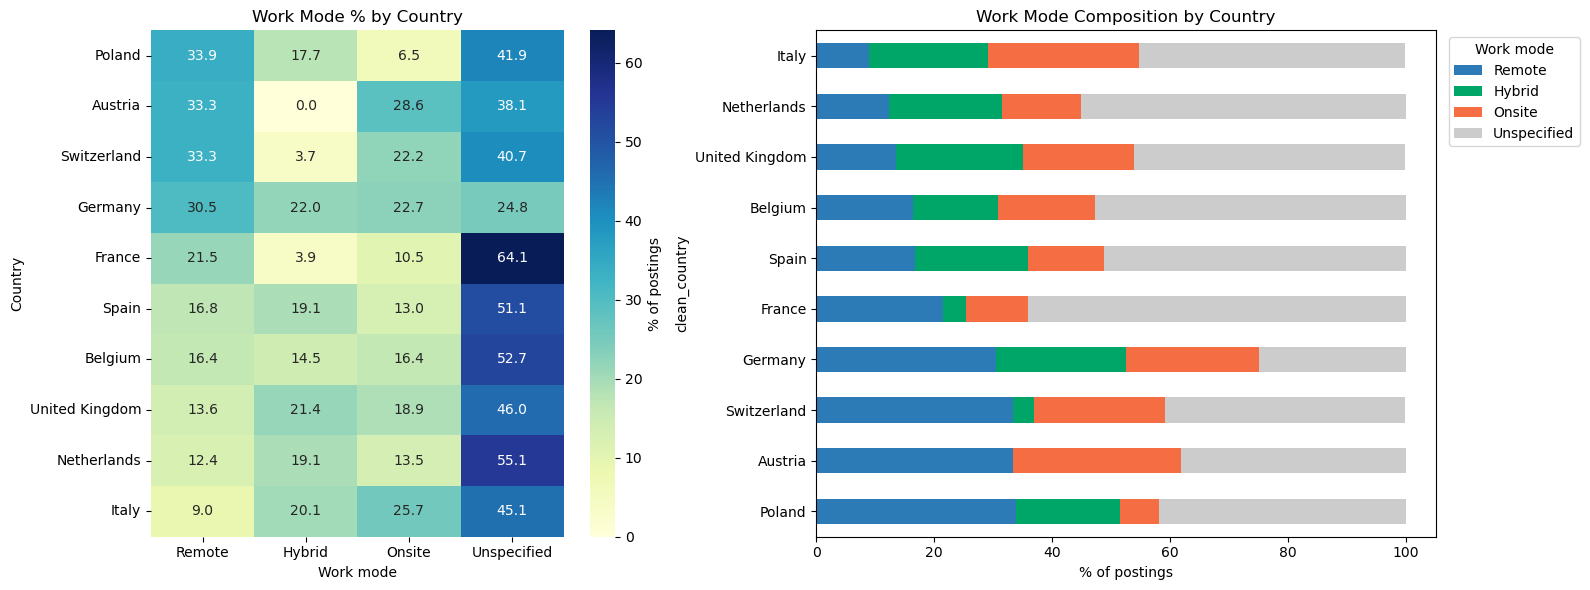

In [43]:


# 4a. Seaborn heatmap of % per country
fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1, 1.2]})
sns.heatmap(
    work_mode_pct, annot=True, fmt=".1f", cmap="YlGnBu",
    cbar_kws={"label": "% of postings"}, ax=axes[0],
)
axes[0].set_title("Work Mode % by Country")
axes[0].set_xlabel("Work mode")
axes[0].set_ylabel("Country")

# 4b. Stacked horizontal bar
work_mode_pct.plot(
    kind="barh", stacked=True, ax=axes[1],
    color=["#2c7bb6", "#00a668", "#f46d43", "#cccccc"],
)
axes[1].set_title("Work Mode Composition by Country")
axes[1].set_xlabel("% of postings")
axes[1].legend(title="Work mode", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 5 - What seniority levels are most requested per country?

% junior / mid / senior per country

In [44]:
seniority_order = ["Junior", "Middle", "Senior", "Intern", "Unspecified"]

# 1. Pivot table: counts of seniority per country
seniority_counts = data_analyst_jobs.pivot_table(
    index="clean_country",
    columns="seniority_level",
    values="id",
    aggfunc="count",
    fill_value=0,
).reindex(columns=seniority_order, fill_value=0)
seniority_counts.index = seniority_counts.index.map(country_names)

# 2. Row-normalize to % per country
seniority_pct = seniority_counts.div(seniority_counts.sum(axis=1), axis=0) * 100
seniority_pct = seniority_pct.round(1).sort_values("Senior", ascending=False)

# 3. Overall distribution as a Series
overall_seniority = (
    data_analyst_jobs["seniority_level"].value_counts(normalize=True)
    .reindex(seniority_order).mul(100).round(1)
)
print("Overall seniority split (%):")
print(overall_seniority.to_string())

display(seniority_pct)

Overall seniority split (%):
seniority_level
Junior          3.1
Middle          0.3
Senior         22.5
Intern         59.9
Unspecified    14.2


seniority_level,Junior,Middle,Senior,Intern,Unspecified
clean_country,,,,,
Germany,0.7,0.0,29.8,62.4,7.1
United Kingdom,4.2,0.2,26.0,46.5,23.1
Poland,6.5,0.3,25.2,50.3,17.7
Spain,3.1,0.8,23.7,56.5,16.0
France,1.2,0.0,19.8,70.8,8.3
Switzerland,0.0,0.0,18.5,66.7,14.8
Italy,4.9,0.0,13.2,72.9,9.0
Netherlands,5.6,3.4,11.2,67.4,12.4
Belgium,1.8,3.6,10.9,61.8,21.8


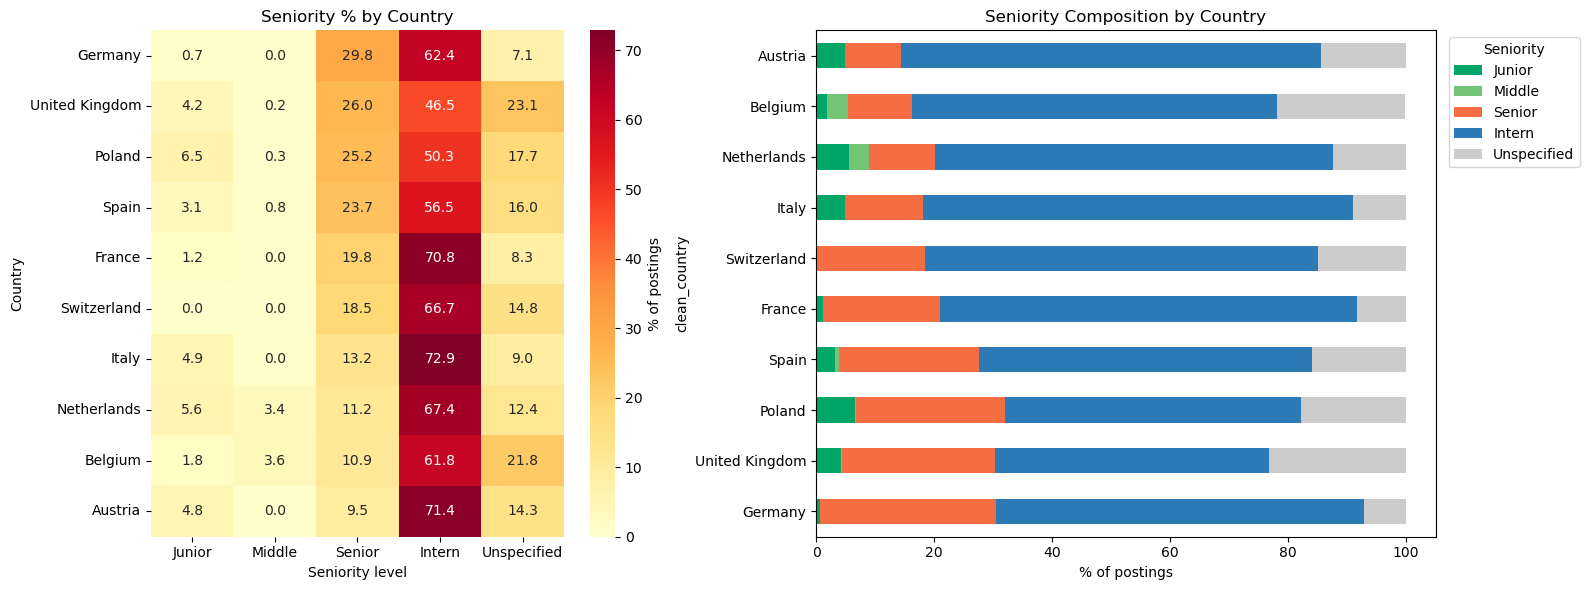

In [45]:
# 4a. Seaborn heatmap of % per country
fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1, 1.2]})
sns.heatmap(
    seniority_pct, annot=True, fmt=".1f", cmap="YlOrRd",
    cbar_kws={"label": "% of postings"}, ax=axes[0],
)
axes[0].set_title("Seniority % by Country")
axes[0].set_xlabel("Seniority level")
axes[0].set_ylabel("Country")

# 4b. Stacked horizontal bar
seniority_pct.plot(
    kind="barh", stacked=True, ax=axes[1],
    color=["#00a668", "#74c476", "#f46d43", "#2c7bb6", "#cccccc"],
)
axes[1].set_title("Seniority Composition by Country")
axes[1].set_xlabel("% of postings")
axes[1].legend(title="Seniority", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 6 -Which countries publish the most jobs per week?

In [46]:
# Use the week start date for clean ordering on the time axis
jobs_weekly = data_analyst_jobs.assign(week=data_analyst_jobs["year_week"].str[:10])
jobs_weekly["country"] = jobs_weekly["clean_country"].map(country_names)

# 1. Pivot table: jobs per week per country
weekly_counts = jobs_weekly.pivot_table(
    index="country",
    columns="week",
    values="id",
    aggfunc="count",
    fill_value=0,
)

# 2. Series: average jobs published per week, per country (the answer)
n_weeks = jobs_weekly["week"].nunique()
avg_jobs_per_week = (weekly_counts.sum(axis=1) / n_weeks).round(1).sort_values(ascending=False)
print(f"Average Data Analyst jobs published per week ({n_weeks} weeks):")
print(avg_jobs_per_week.to_string())

display(weekly_counts)

Average Data Analyst jobs published per week (25 weeks):
country
France            30.5
United Kingdom    25.8
Poland            12.4
Germany           11.3
Italy              5.8
Spain              5.2
Netherlands        3.6
Belgium            2.2
Switzerland        1.1
Austria            0.8


week,2025-12-29,2026-01-05,2026-01-12,2026-01-19,2026-01-26,2026-02-02,2026-02-09,2026-02-16,2026-02-23,2026-03-02,...,2026-04-13,2026-04-20,2026-04-27,2026-05-04,2026-05-11,2026-05-18,2026-05-25,2026-06-01,2026-06-08,2026-06-15
country,,,,,,,,,,,,,,,,,,,,,
Austria,0,0,0,0,0,0,0,0,0,1,...,0,0,0,3,2,3,3,5,3,0
Belgium,0,0,0,0,1,0,0,0,0,0,...,1,3,0,3,1,12,5,9,12,2
France,0,3,2,7,1,7,2,4,6,8,...,22,26,17,25,39,83,93,130,168,25
Germany,0,13,0,1,1,0,2,1,4,2,...,5,11,9,16,55,24,30,30,40,18
Italy,1,0,0,0,0,0,0,0,1,0,...,5,4,5,11,6,15,16,18,29,26
Netherlands,0,2,0,0,0,1,1,0,0,1,...,1,7,5,3,2,3,17,11,23,6
Poland,0,0,2,0,1,2,1,1,0,0,...,9,18,12,16,29,33,32,30,47,45
Spain,0,0,2,0,3,2,0,0,1,2,...,5,7,8,12,8,6,11,10,27,8
Switzerland,0,0,0,0,0,0,0,0,0,0,...,0,0,1,1,1,3,0,7,13,0


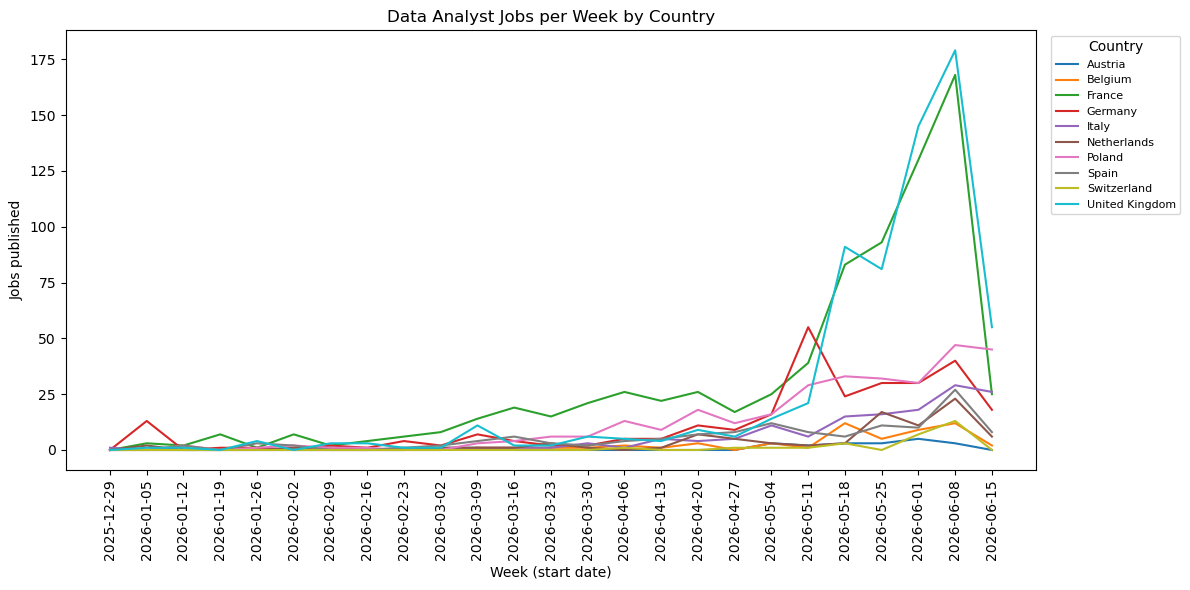

In [47]:
# 3. Seaborn line plot: weekly trend per country
plt.figure(figsize=(12, 6))
weekly_long = weekly_counts.T.reset_index().melt(id_vars="week", var_name="country", value_name="jobs")
ax = sns.lineplot(data=weekly_long, x="week", y="jobs", hue="country")
ax.set_title("Data Analyst Jobs per Week by Country")
ax.set_xlabel("Week (start date)")
ax.set_ylabel("Jobs published")
ax.tick_params(axis="x", rotation=90)
ax.legend(title="Country", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

/var/folders/b4/svxttqvs5zg_rg_drrxn_vf00000gn/T/ipykernel_6583/2882236575.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




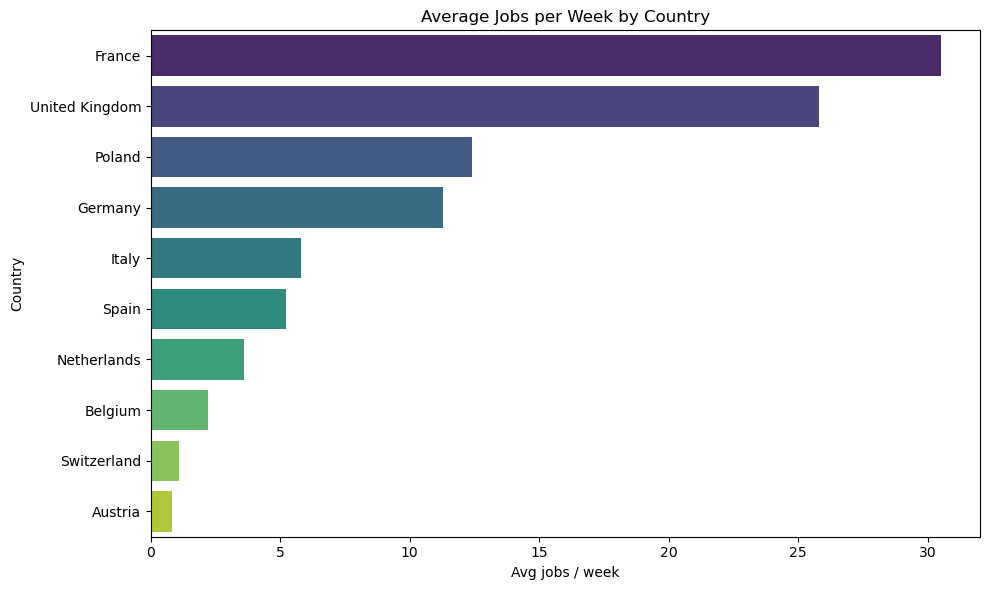

In [48]:
# 4. Seaborn bar plot: avg jobs per week per country
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=avg_jobs_per_week.values, y=avg_jobs_per_week.index, palette="viridis")
ax.set_title("Average Jobs per Week by Country")
ax.set_xlabel("Avg jobs / week")
ax.set_ylabel("Country")
plt.tight_layout()
plt.show()